🔍 VideoChain EDA Initialization...


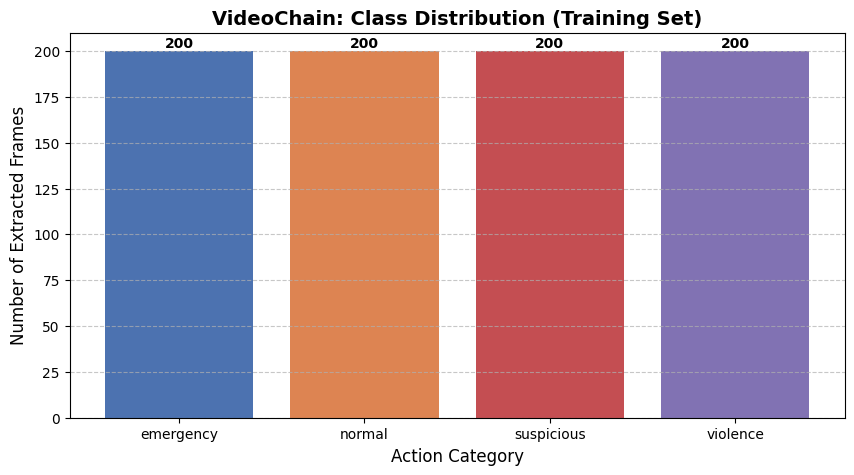

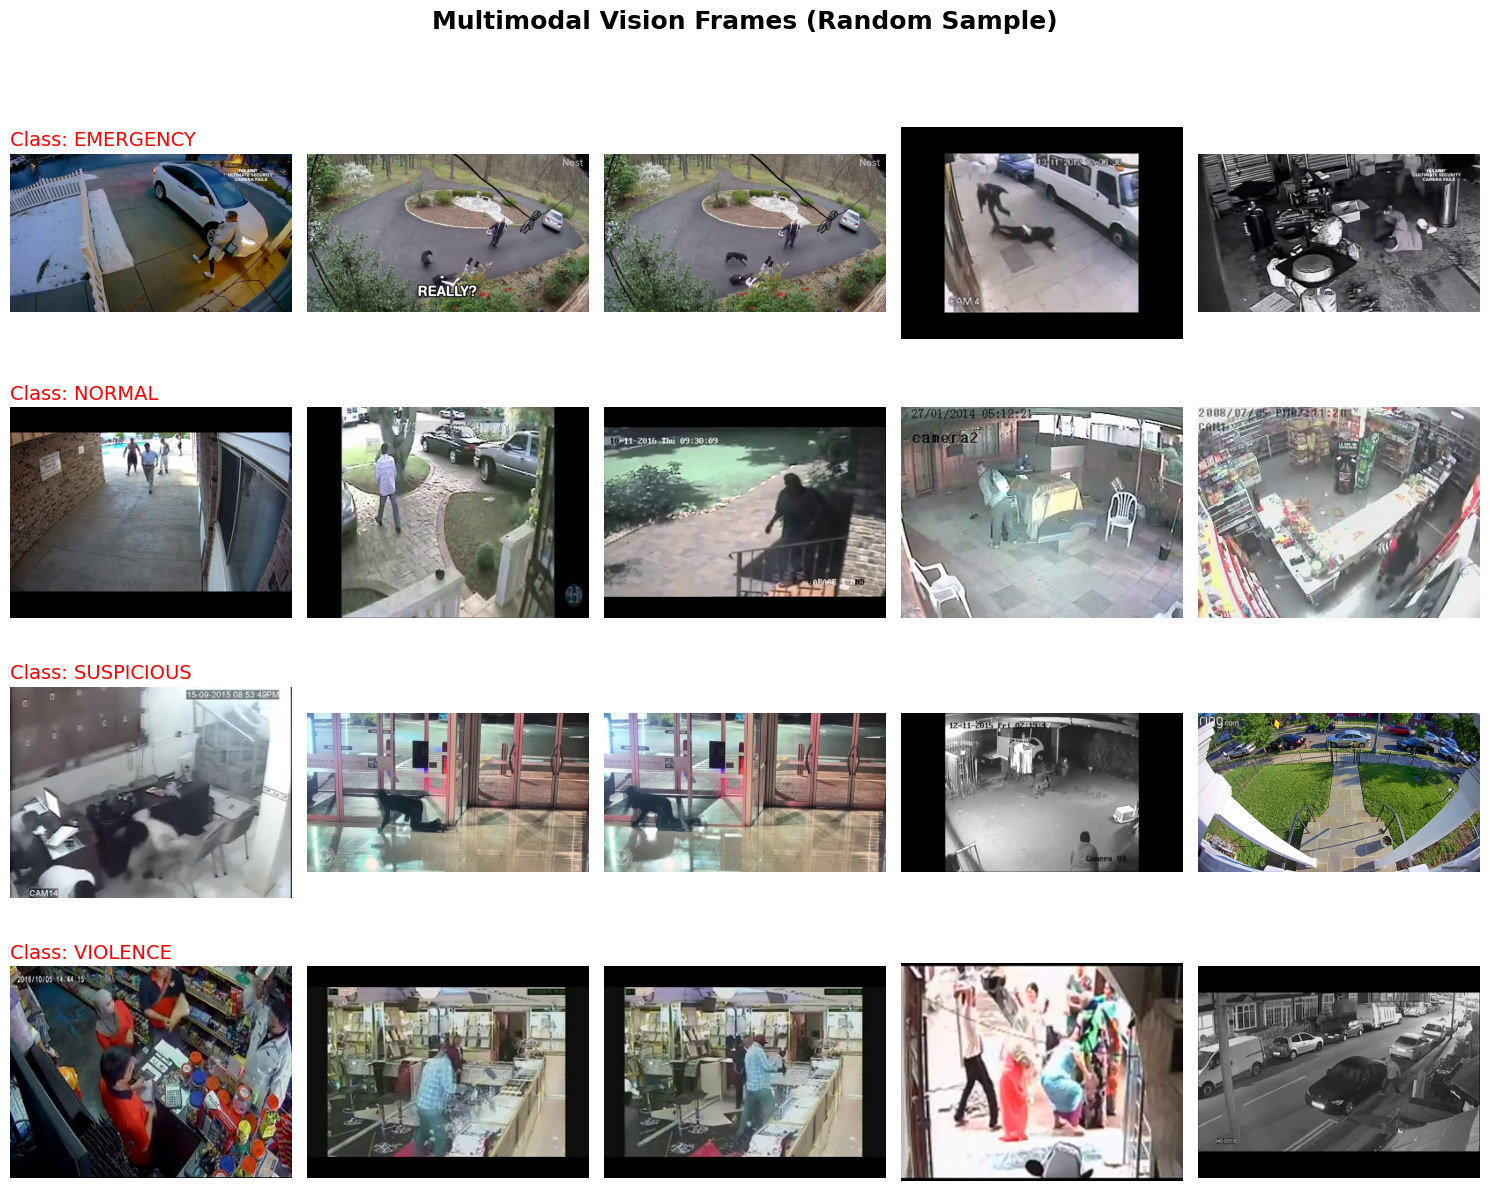

In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Set your data directory (assuming you run this from the project root)
# If running inside the 'notebooks' folder, use "../data/train"
data_dir = "../data/train" 

# Safely get classes (ignoring hidden files like .gitkeep)
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

print("🔍 VideoChain EDA Initialization...")

# ==========================================
# 1. CLASS DISTRIBUTION CHART
# ==========================================
class_counts = {c: len(os.listdir(os.path.join(data_dir, c))) for c in classes}

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['#4C72B0', '#DD8452', '#C44E52', '#8172B3'])
plt.title("VideoChain: Class Distribution (Training Set)", fontsize=14, fontweight='bold')
plt.ylabel("Number of Extracted Frames", fontsize=12)
plt.xlabel("Action Category", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for i, v in enumerate(class_counts.values()):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.show()

print("\n")

# ==========================================
# 2. RANDOM SAMPLE GRID VISUALIZATION
# ==========================================
# We want 5 sample images per class
num_samples = 5
fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 3 * len(classes)))
fig.suptitle("Multimodal Vision Frames (Random Sample)", fontsize=18, fontweight='bold', y=1.02)

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(('.jpg', '.png'))]
    
    # Safely sample images
    sample_imgs = random.sample(images, min(len(images), num_samples))
    
    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        
        # Display the image
        axes[i, j].imshow(img)
        axes[i, j].axis('off') # Hide the grid lines for a cleaner look
        
        # Add a title to the first image in each row
        if j == 0:
            axes[i, j].set_title(f"Class: {cls.upper()}", fontsize=14, loc='left', color='red')

plt.tight_layout()
plt.show()